---
title: "A Hands-On Demonstration with the CHS Working Sample"
subtitle: "From Appendix A9 measures to a simple skill-formation regression"
author: "Child Skill Formation"
date: "2026-09-01"
jupyter: python3
format:
  html:
    toc: true
    toc-depth: 2
    code-fold: false
    html-math-method: katex
execute:
  echo: true
  warning: false
  error: false
---

In [1]:
#| label: setup
#| include: false

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

# Purpose

This page is a **teaching demonstration**, not a replication of the full
Cunha--Heckman--Schennach (CHS) estimator. We use the Appendix A9-style
teaching extract created from the local NLSY79 files and then make the first
steps of a skill-formation analysis visible:

1. define the working sample;
2. inspect which measures represent cognitive skill, noncognitive skill, and
   investment in each developmental period;
3. audit missingness;
4. construct transparent, period-specific proxy measures; and
5. estimate a simple benchmark production equation.

The working sample is **2,219 children**: firstborn children in the CHS
white-sample definition who have all three child measure types somewhere in
the A9 periods and a complete maternal A9 measurement vector. This is a
working restriction for the demonstration. The published CHS reference
sample is reported separately as (N=2{,}207).

::: {.callout-warning}
## Important interpretation

The regressions below use observed proxies. They do **not** recover latent
factors, correct for measurement error, identify a causal investment effect,
or impose the full CHS/AW age-invariance and normalization framework.
:::

# 1. Load the teaching extract

The source files are generated by [`make_chs_white_children.R`](../make_chs_white_children.R).
The path search makes the page usable when the working directory is either
the repository root or `estimation_demo/`.

In [2]:
#| label: load-data

DATA_FILES = {
    "period": "chs_white_firstborn_appendix_a9_period.csv",
    "child": "chs_white_firstborn_appendix_a9_child.csv",
}

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/content/child-skill-formation"),
    Path("/content/Child Skill Formation"),
]

def find_data_file(filename):
    candidates = []
    for root in candidate_roots:
        candidates.extend([
            root / "data" / "derived" / filename,
            root / filename,
        ])
    for path in candidates:
        if path.exists():
            return path
    searched = "\n".join(f"- {path}" for path in candidates)
    raise FileNotFoundError(
        f"Could not find {filename}. Searched:\n{searched}\n\n"
        "In Colab, upload the two derived CSV files or clone the repository."
    )

period_path = find_data_file(DATA_FILES["period"])
child_path = find_data_file(DATA_FILES["child"])

period = pd.read_csv(period_path)
child = pd.read_csv(child_path)

print(f"Period file: {period_path}")
print(f"Child file:  {child_path}")
print(f"Period rows: {len(period):,}")
print(f"Child rows:  {len(child):,}")

Period file: C:\Users\kangh\Dropbox\Child Skill Formation\data\derived\chs_white_firstborn_appendix_a9_period.csv
Child file:  C:\Users\kangh\Dropbox\Child Skill Formation\data\derived\chs_white_firstborn_appendix_a9_child.csv
Period rows: 22,560
Child rows:  2,820


# 2. Define the 2,219-child working sample

The restriction is implemented in code rather than typed into a table. This
is useful because every later result can be traced back to the sample rule.

In [3]:
#| label: define-working-sample

has_three_types = child["child_has_all_three_a9_types"].fillna(False).astype(bool)
maternal_complete = child["maternal_a9_complete"].fillna(False).astype(bool)

working_ids = set(
    child.loc[has_three_types & maternal_complete, "child_id"].astype(int)
)

working = period.loc[period["child_id"].isin(working_ids)].copy()
working["child_id"] = working["child_id"].astype(int)
working = working.sort_values(["child_id", "period"])

assert working["child_id"].nunique() == 2_219

sample_counts = pd.DataFrame({
    "Sample rule": [
        "Race code 3 and firstborn",
        "At least one age-eligible A9 child measure",
        "All three A9 child measure types",
        "Complete maternal A9 measurement vector",
        "Working sample: both child and maternal restrictions",
        "Published CHS reference sample",
    ],
    "Children": [
        len(child),
        int(child["child_has_any_a9_measure"].fillna(False).sum()),
        int(has_three_types.sum()),
        int(maternal_complete.sum()),
        len(working_ids),
        2_207,
    ],
})

display(sample_counts.style.hide(axis="index"))

Sample rule,Children
Race code 3 and firstborn,2820
At least one age-eligible A9 child measure,2760
All three A9 child measure types,2331
Complete maternal A9 measurement vector,2650
Working sample: both child and maternal restrictions,2219
Published CHS reference sample,2207


The two numbers that should be kept separate are:

- (2{,}219): our transparent working sample under the joint observable
  restriction;
- (2{,}207): the published CHS reference count.

The 12-child difference is not silently removed. Matching the published
likelihood sample exactly would require the authors' original prepared data
and any additional flags used in estimation.

# 3. What is measured in each developmental period?

The Appendix A9 construction chooses a representative measure for each
factor and period. The selected measure changes over the life cycle. That is
why this table is part of the estimation procedure, not merely documentation.

In [4]:
#| label: a9-map

age_labels = {
    1: "Birth",
    2: "1--2",
    3: "3--4",
    4: "5--6",
    5: "7--8",
    6: "9--10",
    7: "11--12",
    8: "13--14",
}

a9_map = (
    working.groupby("period", as_index=False)
    .agg({
        "cognitive_measure_name": "first",
        "non_cognitive_measure_name": "first",
        "investment_measure_name": "first",
    })
    .rename(columns={
        "period": "Period",
        "cognitive_measure_name": "Cognitive measure",
        "non_cognitive_measure_name": "Noncognitive measure",
        "investment_measure_name": "Investment measure",
    })
)
a9_map.insert(1, "Age range", a9_map["Period"].map(age_labels))
display(a9_map.style.hide(axis="index"))

Period,Age range,Cognitive measure,Noncognitive measure,Investment measure
1,Birth,Weight at birth,Temperament Difficulty,Frequency Mother Reads to Child
2,1--2,Motor-Social Development,Temperament Difficulty,Frequency Mother Reads to Child
3,3--4,Peabody Picture Vocabulary Test,BPI Antisocial Behavior,Frequency Mother Reads to Child
4,5--6,PIAT Mathematics,BPI Antisocial Behavior,Frequency Child Goes to Musical Shows
5,7--8,PIAT Mathematics,BPI Antisocial Behavior,Frequency Child Goes to Musical Shows
6,9--10,PIAT Mathematics,BPI Antisocial Behavior,Frequency Child Goes to Musical Shows
7,11--12,PIAT Mathematics,BPI Antisocial Behavior,Frequency Child Goes to Musical Shows
8,13--14,PIAT Mathematics,BPI Antisocial Behavior,Frequency Child Goes to Musical Shows


For example, cognitive skill is represented by birth weight in the first
period, MSD in the second, PPVT in the third, and PIAT Mathematics from the
fourth period onward. This is a useful bridge from the conceptual latent
factor (	heta_t) to the actual variables in the data, but it does not make
the observed measures error-free.

# 4. Audit the signal available in the data

Before estimating anything, count the nonmissing observations by period. A
working sample can contain 2,219 children while a particular transition uses
fewer observations because a selected measure is missing in that period.

In [5]:
#| label: missingness-table

measure_columns = {
    "cognitive_measure": "Cognitive",
    "non_cognitive_measure": "Noncognitive",
    "investment_measure": "Investment",
}

coverage_rows = []
for period_number, group in working.groupby("period"):
    row = {
        "Period": period_number,
        "Age range": age_labels[period_number],
        "Children": len(group),
    }
    for column, label in measure_columns.items():
        row[f"{label} N"] = int(group[column].notna().sum())
        row[f"{label} %"] = 100 * group[column].notna().mean()
    coverage_rows.append(row)

coverage = pd.DataFrame(coverage_rows)
display(
    coverage.style
    .format({column: "{:.1f}" for column in coverage.columns if column.endswith(" %")})
    .hide(axis="index")
)

Period,Age range,Children,Cognitive N,Cognitive %,Noncognitive N,Noncognitive %,Investment N,Investment %
1,Birth,2219,2185,98.5,459,20.7,483,21.8
2,1--2,2219,1065,48.0,548,24.7,1117,50.3
3,3--4,2219,1052,47.4,709,32.0,1334,60.1
4,5--6,2219,1411,63.6,1458,65.7,736,33.2
5,7--8,2219,1500,67.6,1548,69.8,1581,71.2
6,9--10,2219,1449,65.3,1495,67.4,1527,68.8
7,11--12,2219,1282,57.8,1335,60.2,1366,61.6
8,13--14,2219,985,44.4,1029,46.4,1051,47.4


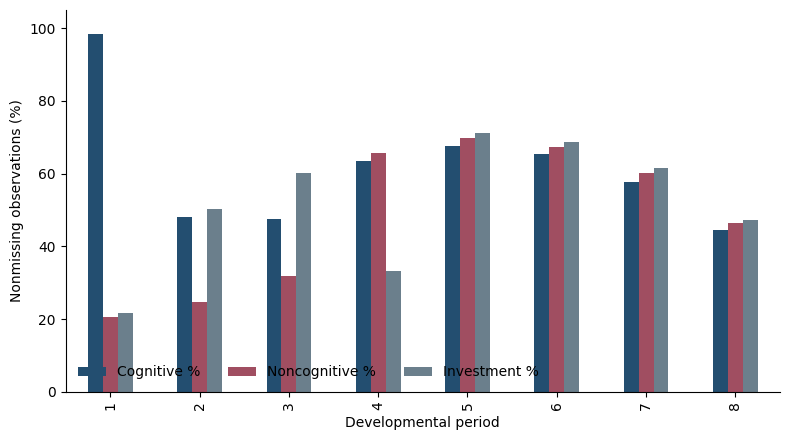

In [6]:
#| label: missingness-plot
#| fig-cap: "Availability of the representative A9 measures in the 2,219-child working sample."

plot_data = coverage.set_index("Period")[["Cognitive %", "Noncognitive %", "Investment %"]]
ax = plot_data.plot(kind="bar", color=["#234e70", "#a04e61", "#6b7f8c"])
ax.set_xlabel("Developmental period")
ax.set_ylabel("Nonmissing observations (%)")
ax.set_ylim(0, 105)
ax.legend(frameon=False, ncol=3, loc="lower left")
plt.tight_layout()
plt.show()

The plot is already teaching us something important: the sample-size
restriction is at the child level, while the usable estimation sample is
transition-specific. This is one reason a production-function exercise must
report its observation rule carefully.

# 5. Build transparent proxy measures

The selected variables have different units: ounces, test scores, frequency
responses, and behavior scores. For this first benchmark, we standardize each
selected measure **within period**:

$$
X^{z}_{it} = \frac{X_{it}-\bar X_t}{s_t}.
$$

This puts the proxies on a comparable numerical scale. It is deliberately a
teaching choice, not the CHS latent-factor normalization and not AW's
age-invariance solution.

In [7]:
#| label: standardize-proxies

def within_period_zscore(series):
    standard_deviation = series.std(ddof=1)
    if pd.isna(standard_deviation) or standard_deviation == 0:
        return series * np.nan
    return (series - series.mean()) / standard_deviation

proxy_map = {
    "cognitive_measure": "cognitive_z",
    "non_cognitive_measure": "noncognitive_z",
    "investment_measure": "investment_z",
}

for source, destination in proxy_map.items():
    working[destination] = working.groupby("period")[source].transform(
        within_period_zscore
    )

working[[
    "child_id", "period", "cognitive_measure", "cognitive_z",
    "non_cognitive_measure", "noncognitive_z",
    "investment_measure", "investment_z",
]].head(8)

,child_id,period,cognitive_measure,cognitive_z,non_cognitive_measure,noncognitive_z,investment_measure,investment_z
0,201,1,139.000,1.109,NaN,NaN,NaN,NaN
1,201,2,11.000,0.446,27.000,0.486,6.000,0.642
2,201,3,NaN,NaN,NaN,NaN,5.000,-0.164
3,201,4,10.000,-1.086,0.000,-0.897,NaN,NaN
4,201,5,24.000,-0.961,NaN,NaN,4.000,2.507
5,201,6,38.000,-0.942,2.000,0.574,2.000,0.212
6,201,7,55.000,0.046,0.000,-0.805,2.000,0.218
7,201,8,NaN,NaN,NaN,NaN,NaN,NaN


The code makes the scale choice visible. If we later replace this step with a
factor model, the rest of the data pipeline can remain largely the same.

# 6. Stack adjacent periods into transitions

The canonical production equation asks how current inputs predict next-period
skill:

$$
\theta_{i,t+1}
=
f_t(\theta_{i,t}, I_{i,t}, \ldots).
$$

Here we use the observable proxies to create one row per child and adjacent
period. We keep the period label so that the benchmark can allow the average
production environment to differ by developmental stage.

In [8]:
#| label: build-transitions

def make_transition_table(data, current_period):
    current = data.loc[data["period"] == current_period, [
        "child_id", "cognitive_z", "noncognitive_z", "investment_z"
    ]].rename(columns={
        "cognitive_z": "cognitive_t",
        "noncognitive_z": "noncognitive_t",
        "investment_z": "investment_t",
    })
    next_period = data.loc[data["period"] == current_period + 1, [
        "child_id", "cognitive_z"
    ]].rename(columns={"cognitive_z": "cognitive_tp1"})

    transition = current.merge(next_period, on="child_id", how="inner")
    transition["period_t"] = current_period
    return transition

transitions = pd.concat(
    [make_transition_table(working, period_number) for period_number in range(1, 8)],
    ignore_index=True,
)

transition_counts = (
    transitions.assign(
        complete=lambda data: data[
            ["cognitive_t", "noncognitive_t", "investment_t", "cognitive_tp1"]
        ].notna().all(axis=1)
    )
    .groupby("period_t", as_index=False)
    .agg(
        **{
            "Transition": ("period_t", lambda x: f"{int(x.iloc[0])} $\\rightarrow$ {int(x.iloc[0]) + 1}"),
            "Child pairs": ("child_id", "size"),
            "Complete rows": ("complete", "sum"),
        }
    )
)

display(transition_counts.drop(columns="period_t").style.hide(axis="index"))

Transition,Child pairs,Complete rows
1 $\rightarrow$ 2,2219,324
2 $\rightarrow$ 3,2219,270
3 $\rightarrow$ 4,2219,435
4 $\rightarrow$ 5,2219,510
5 $\rightarrow$ 6,2219,1147
6 $\rightarrow$ 7,2219,1079
7 $\rightarrow$ 8,2219,818


The next-period outcome is missing for some child-period observations, so the
regression sample is smaller than 2,219. This is not a contradiction: the
2,219 figure defines the child-level working sample, while each regression
uses the observations needed for its own variables.

# 7. Estimate a simple benchmark production equation

The following regression is intentionally modest:

$$
\widehat{\mathrm{Cognitive}}_{i,t+1}
=
\beta_{0,t}
+\beta_1\mathrm{Cognitive}_{i,t}
+\beta_2\mathrm{Noncognitive}_{i,t}
+\beta_3\mathrm{Investment}_{i,t}
+u_{i,t+1}.
$$

The period fixed effects (\beta_{0,t}) absorb average differences across
transitions. The coefficients should be read as associations between proxy
measures, not as causal production-function parameters.

In [9]:
#| label: benchmark-regression

regression_data = transitions.dropna(
    subset=["cognitive_t", "noncognitive_t", "investment_t", "cognitive_tp1"]
).copy()

benchmark_fit = smf.ols(
    "cognitive_tp1 ~ cognitive_t + noncognitive_t + investment_t + C(period_t)",
    data=regression_data,
).fit(cov_type="HC1")

benchmark_table = pd.DataFrame({
    "Coefficient": benchmark_fit.params,
    "Robust SE": benchmark_fit.bse,
    "p-value": benchmark_fit.pvalues,
}).loc[[
    "cognitive_t", "noncognitive_t", "investment_t"
]]

print(f"Estimation observations: {len(regression_data):,}")
display(benchmark_table)

Estimation observations: 4,583


,Coefficient,Robust SE,p-value
cognitive_t,0.535,0.015,0.000
noncognitive_t,-0.073,0.013,0.000
investment_t,0.054,0.012,0.000


The coefficient on `investment_t` is the benchmark association between the
current investment proxy and next-period cognitive skill, conditional on the
current skill proxies and period effects. It is not yet the CHS investment
productivity parameter because the regressors remain noisy and potentially
endogenous.

# 8. Add the skill--investment interaction

To connect the code to the complementarity discussion, add an interaction:

$$
\widehat{\mathrm{Cognitive}}_{i,t+1}
= \cdots
+\beta_3 I_{i,t}
+\beta_4 I_{i,t}\times \mathrm{Cognitive}_{i,t}
+u_{i,t+1}.
$$

In this proxy regression, (\beta_4) is a **direct/log-style interaction on
the chosen proxy scale**. It is not automatically the dynamic complementarity
of the full multi-period technology.

In [10]:
#| label: interaction-regression

interaction_fit = smf.ols(
    "cognitive_tp1 ~ cognitive_t + noncognitive_t + investment_t "
    "+ cognitive_t:investment_t + C(period_t)",
    data=regression_data,
).fit(cov_type="HC1")

interaction_table = pd.DataFrame({
    "Coefficient": interaction_fit.params,
    "Robust SE": interaction_fit.bse,
    "p-value": interaction_fit.pvalues,
}).loc[[
    "cognitive_t", "investment_t", "cognitive_t:investment_t"
]]

display(interaction_table)

,Coefficient,Robust SE,p-value
cognitive_t,0.536,0.015,0.000
investment_t,0.055,0.012,0.000
cognitive_t:investment_t,-0.012,0.014,0.400


The implied investment association at three illustrative current-skill
levels is:

In [11]:
#| label: marginal-investment-association

beta_investment = interaction_fit.params["investment_t"]
beta_interaction = interaction_fit.params["cognitive_t:investment_t"]

marginal_effects = pd.DataFrame({
    "Current cognitive proxy": [-1, 0, 1],
    "Implied investment coefficient": [
        beta_investment - beta_interaction,
        beta_investment,
        beta_investment + beta_interaction,
    ],
})

display(marginal_effects.style.hide(axis="index"))

Current cognitive proxy,Implied investment coefficient
-1,0.066896
0,0.054978
1,0.043060


This is a convenient classroom visualization of heterogeneity in investment
associations. To interpret it as a structural complementarity result, we
would still need a valid measurement model, an identified investment
equation, and a carefully specified dynamic technology.

# 9. What has—and has not—been estimated?

The notebook has now taken the data from a child-level sample rule to a
working regression:

$$
\text{raw NLSY files}
\rightarrow
\text{A9 representative measures}
\rightarrow
\text{2,219-child working sample}
\rightarrow
\text{period transitions}
\rightarrow
\text{proxy regression}.
$$

The next methodological steps would be:

- estimate latent cognitive and noncognitive factors from multiple measures;
- impose and examine the relevant scale and age-invariance restrictions;
- model measurement error rather than treating the proxy as the factor;
- address investment endogeneity with a clearly justified strategy; and
- estimate the multi-stage technology jointly or sequentially according to
  the chosen identification argument.

This is why the page is useful as a first demonstration: every row and
coefficient is executable, while the distinction between a transparent proxy
exercise and the full CHS/AW estimator remains explicit.

## Running the page

From the repository root:

```bash
quarto render estimation_demo/chs_working_sample_demo.qmd
```

To use the same source interactively, open the accompanying `.ipynb` in
Jupyter or upload it to Google Colab. Colab users need to provide the two
derived CSV files in `data/derived/`, or clone the repository first.